In [2]:
# from google.colab import files
# files.upload()

In [4]:
import pandas as pd

# Replace with the actual filename after upload
df = pd.read_csv(r"C:\Users\raman\Desktop\Kanchan_Material\01_AirTransportAndLogistics\Course_Material\Semester_03\Research Task\12683453\flights.csv", delimiter=",", encoding="utf-8", header=0)
print(df.columns)

df.dtypes

Index(['flight', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'speed', 'payload', 'altitude', 'date',
       'time_day', 'route'],
      dtype='object')


C:\Users\raman\AppData\Local\Temp\ipykernel_7488\2129182278.py:4: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\raman\Desktop\Kanchan_Material\01_AirTransportAndLogistics\Course_Material\Semester_03\Research Task\12683453\flights.csv", delimiter=",", encoding="utf-8", header=0)


flight                     int64
time                     float64
wind_speed               float64
wind_angle               float64
battery_voltage          float64
battery_current          float64
position_x               float64
position_y               float64
position_z               float64
orientation_x            float64
orientation_y            float64
orientation_z            float64
orientation_w            float64
velocity_x               float64
velocity_y               float64
velocity_z               float64
angular_x                float64
angular_y                float64
angular_z                float64
linear_acceleration_x    float64
linear_acceleration_y    float64
linear_acceleration_z    float64
speed                    float64
payload                  float64
altitude                  object
date                      object
time_day                  object
route                     object
dtype: object

Loading dataset...
Loaded: 257896 rows.
Rows after cleaning: 255711
Feature extraction complete.
Flight segmentation complete.
segment
hover         77769
climb         69743
descent       52105
cruise        28110
transition    27984
Name: count, dtype: int64
Saved: M100_features.csv
Saved: M100_segments.csv


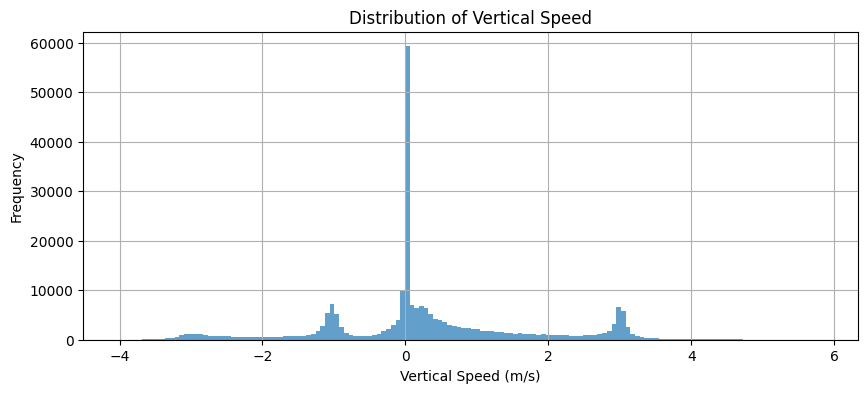

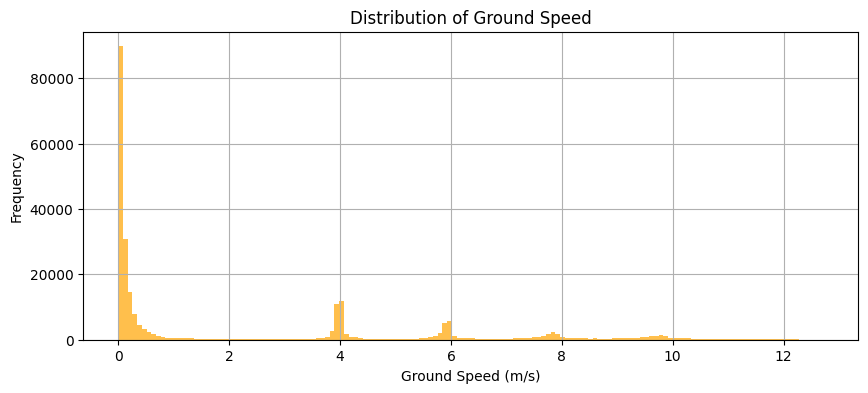

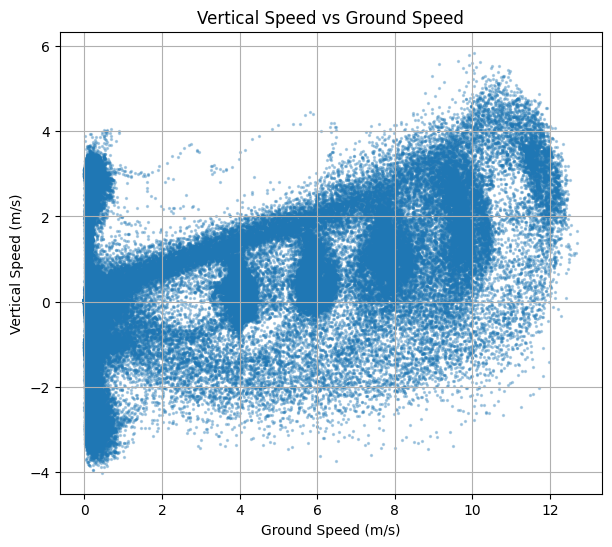

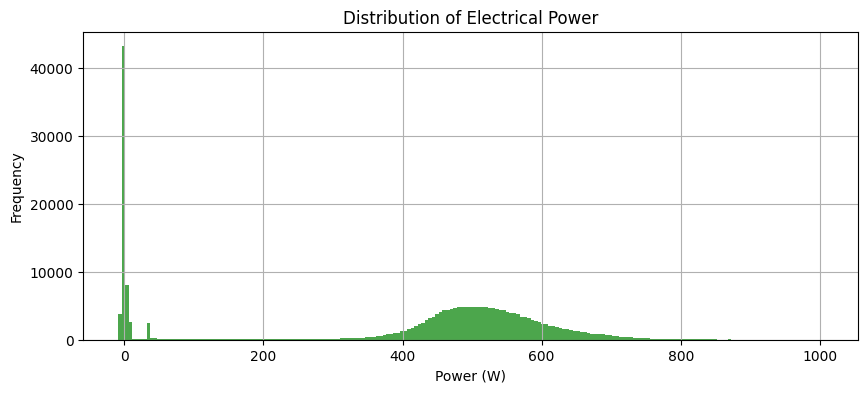

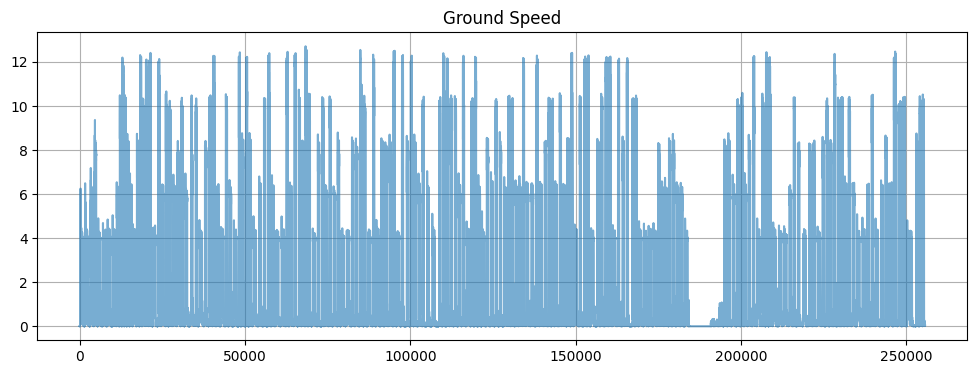

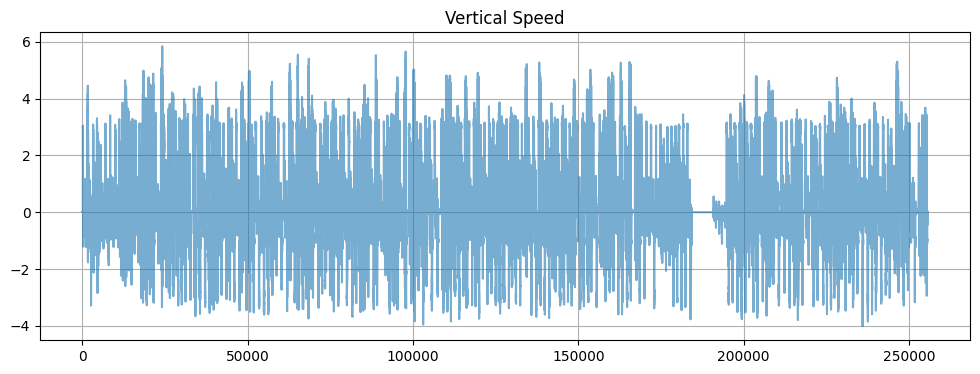

In [6]:
"""
TASK 1 — Data Analysis & Feature Extraction for DJI M100
Final Version for Dataset with Float Timestamp and Object Altitude
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# Utility Functions
# ==========================================================

def compute_ground_speed(df):
    return np.sqrt(df["velocity_x"]**2 + df["velocity_y"]**2)


def compute_accel_mag(df):
    return np.sqrt(
        df["linear_acceleration_x"]**2 +
        df["linear_acceleration_y"]**2 +
        df["linear_acceleration_z"]**2
    )


def compute_wind_vector(df):
    rad = np.deg2rad(df["wind_angle"])
    wind_x = -df["wind_speed"] * np.cos(rad)
    wind_y = -df["wind_speed"] * np.sin(rad)
    return wind_x, wind_y


def compute_airspeed(df, wind_x, wind_y):
    return np.sqrt(
        (df["velocity_x"] - wind_x)**2 +
        (df["velocity_y"] - wind_y)**2
    )


# ==========================================================
# Main Processor Class
# ==========================================================

class M100FeatureExtractor:

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None

    def load_data(self):
        print("Loading dataset...")
        df = pd.read_csv(self.filepath, low_memory=False)
        print(f"Loaded: {len(df)} rows.")
        self.df = df

    def clean_data(self):
        df = self.df.copy()

        df.drop_duplicates(inplace=True)
        df = df[df["battery_voltage"] > 0]
        df = df[df["battery_current"] > -20]
        df = df[df["speed"] >= 0]
        df.dropna(inplace=True)

        # Fix altitude (was object → must convert)
        df["altitude"] = pd.to_numeric(df["altitude"], errors="coerce")

        # Time is float timestamp (seconds)
        df["time"] = pd.to_numeric(df["time"], errors="coerce")

        # Remove any rows where conversion failed
        df = df.dropna(subset=["time", "altitude"])

        self.df = df
        print(f"Rows after cleaning: {len(df)}")

    def add_features(self):
        df = self.df

        df["ground_speed"] = compute_ground_speed(df)
        df["vertical_speed"] = df["velocity_z"]
        df["accel_mag"] = compute_accel_mag(df)

        df["P_real"] = df["battery_voltage"] * df["battery_current"]

        df["dt"] = df["time"].diff().fillna(0)

        df["E_increment"] = df["P_real"] * df["dt"]
        df["E_cum_Wh"] = df["E_increment"].cumsum() / 3600.0

        wind_x, wind_y = compute_wind_vector(df)
        df["wind_x"] = wind_x
        df["wind_y"] = wind_y
        df["airspeed"] = compute_airspeed(df, wind_x, wind_y)

        df.rename(columns={"payload": "payload_g"}, inplace=True)

        df["distance_increment"] = np.sqrt(
            df["velocity_x"]**2 +
            df["velocity_y"]**2 +
            df["velocity_z"]**2
        ) * df["dt"]

        df["distance_cum"] = df["distance_increment"].cumsum()

        df["altitude_change"] = df["altitude"].diff().fillna(0)

        self.df = df
        print("Feature extraction complete.")

    def segment_flight(self):
        df = self.df.copy()
        df["segment"] = "transition"

        df.loc[df["vertical_speed"] > 0.7, "segment"] = "climb"
        df.loc[df["vertical_speed"] < -0.7, "segment"] = "descent"

        cruise_mask = (df["segment"] == "transition") & (df["ground_speed"] > 4.0)
        df.loc[cruise_mask, "segment"] = "cruise"

        hover_mask = (df["segment"] == "transition") & \
                     (df["ground_speed"] < 0.8) & \
                     (df["vertical_speed"].abs() < 0.3)
        df.loc[hover_mask, "segment"] = "hover"

        self.df = df
        print("Flight segmentation complete.")
        print(df["segment"].value_counts())

    def save_outputs(self):
        self.df.to_csv("M100_features.csv", index=False)

        self.df[[
            "segment", "time", "ground_speed", "vertical_speed",
            "altitude", "distance_cum"
        ]].to_csv("M100_segments.csv", index=False)

        print("Saved: M100_features.csv")
        print("Saved: M100_segments.csv")

    def plot_diagnostics(self):
        df = self.df

        plt.figure(figsize=(12, 4))
        plt.plot(df["ground_speed"], alpha=0.6)
        plt.title("Ground Speed")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(12, 4))
        plt.plot(df["vertical_speed"], alpha=0.6)
        plt.title("Vertical Speed")
        plt.grid(True)
        plt.show()


# ==========================================================
# MAIN EXECUTION
# ==========================================================

if __name__ == "__main__":
    processor = M100FeatureExtractor(r".\12683453\flights.csv")
    processor.load_data()
    processor.clean_data()
    processor.add_features()
    processor.segment_flight()
    processor.save_outputs()

    # ======================================================
    # HISTOGRAM SECTION — Justification for Segmentation
    # ======================================================

    df = processor.df

    # Vertical speed
    plt.figure(figsize=(10,4))
    plt.hist(df["vertical_speed"], bins=150, alpha=0.7)
    plt.title("Distribution of Vertical Speed")
    plt.xlabel("Vertical Speed (m/s)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Ground speed
    plt.figure(figsize=(10,4))
    plt.hist(df["ground_speed"], bins=150, alpha=0.7, color='orange')
    plt.title("Distribution of Ground Speed")
    plt.xlabel("Ground Speed (m/s)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Scatter: Vz vs V
    plt.figure(figsize=(7,6))
    plt.scatter(df["ground_speed"], df["vertical_speed"], s=2, alpha=0.3)
    plt.title("Vertical Speed vs Ground Speed")
    plt.xlabel("Ground Speed (m/s)")
    plt.ylabel("Vertical Speed (m/s)")
    plt.grid(True)
    plt.show()

    # Power distribution
    plt.figure(figsize=(10,4))
    plt.hist(df["P_real"], bins=200, alpha=0.7, color='green')
    plt.title("Distribution of Electrical Power")
    plt.xlabel("Power (W)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Final system diagnostics
    processor.plot_diagnostics()


In [8]:
from utils import clean_flight_df, plot_flight_altitude_speed, MAE, RMSE, MAPE

In [10]:
flight_id = 79
d = df[df["flight"] == flight_id].copy()

# ------------------ Define colors for phases ------------------
phase_colors = {
    "climb":   "rgba(0,255,0,0.25)",      # light green
    "descent": "rgba(255,0,0,0.25)",      # light red
    "hover":   "rgba(255,165,0,0.25)",    # light orange
    "cruise":  "rgba(0,0,255,0.25)",      # light blue
    "taxi":    "rgba(255,255,0,0.25)",    # light yellow
    "other":   "rgba(150,150,150,0.15)"   # light gray
}

# ------------------ Build customdata for hover ------------------
customdata = np.stack((
    d["velocity_z"],
    d["ground_speed"],
    d["segment"]
), axis=-1)

fig = plot_flight_altitude_speed(
    d,
    customdata=customdata,
    phase_colors=phase_colors,
    flight_id=flight_id,
    show=True
)

KeyError: 'altitude_measured'

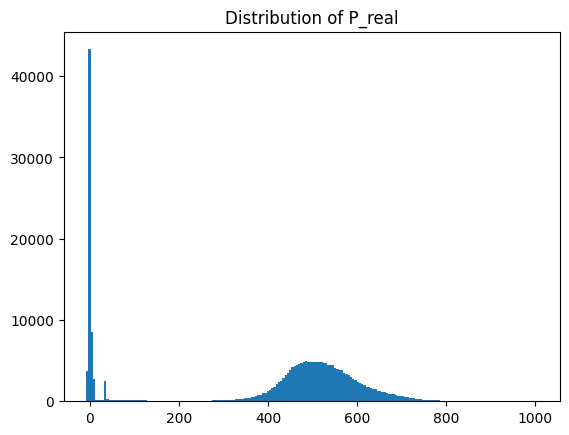

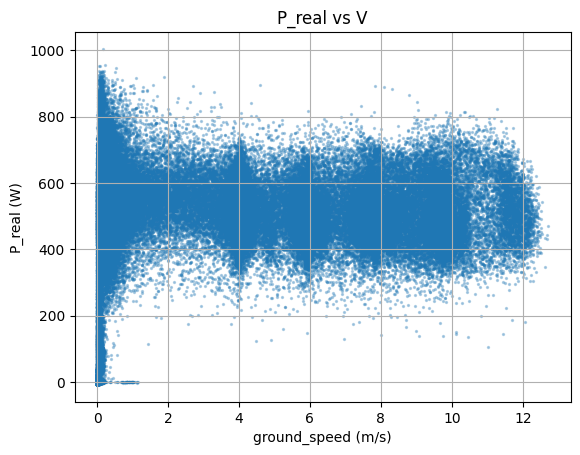

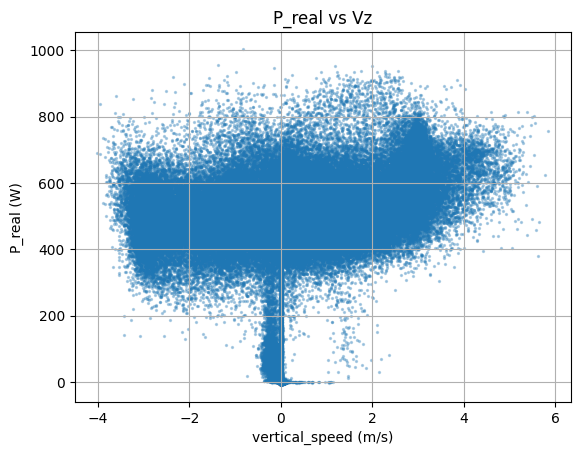

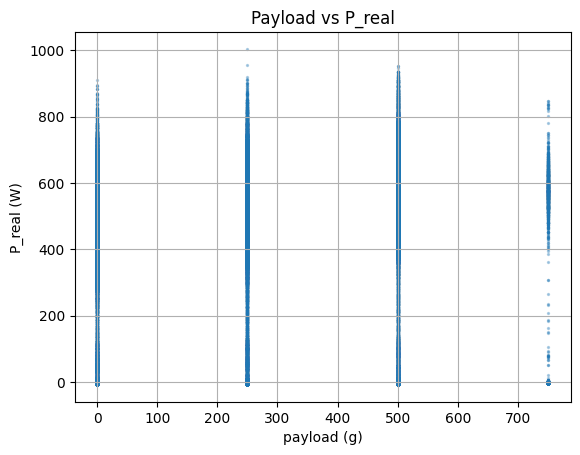

In [ ]:
import matplotlib.pyplot as plt
df = pd.read_csv("M100_features.csv", low_memory=False)

plt.hist(df["P_real"], bins=200)
plt.title("Distribution of P_real")
plt.show()

plt.scatter(df["ground_speed"], df["P_real"], s=2, alpha=0.3)
plt.xlabel("ground_speed (m/s)")
plt.ylabel("P_real (W)")
plt.title("P_real vs V")
plt.grid(True)
plt.show()

plt.scatter(df["vertical_speed"], df["P_real"], s=2, alpha=0.3)
plt.xlabel("vertical_speed (m/s)")
plt.ylabel("P_real (W)")
plt.title("P_real vs Vz")
plt.grid(True)
plt.show()

plt.scatter(df["payload_g"], df["P_real"], s=2, alpha=0.3)
plt.xlabel("payload (g)")
plt.ylabel("P_real (W)")
plt.title("Payload vs P_real")
plt.grid(True)
plt.show()

In [24]:
# ======================================================
# TASK 2 — PHYSICS-BASED POWER MODEL (FINAL CLEAN VERSION)
# ======================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------
# 1. Load Dataset (from Task 1)
# ------------------------------------------------------
df = pd.read_csv("M100_features.csv", low_memory=False)

P_real     = df["P_real"].values
V_air      = df["airspeed"].values
Vz         = df["vertical_speed"].values
segment    = df["segment"].values
payload_kg = df["payload_g"].values / 1000.0

# ------------------------------------------------------
# 2. Physical Parameters for DJI M100
# ------------------------------------------------------
g   = 9.81
rho = 1.225

M0   = 3.68                      # empty mass [kg]
mass = M0 + payload_kg           # total mass [kg]
W    = mass * g                  # weight [N]

# Rotor geometry (13-inch props)
R_prop = 0.165                   # rotor radius [m]
A_rot  = np.pi * R_prop**2       # single rotor disk area [m^2]
A_tot  = 4 * A_rot               # total rotor disk area [m^2]

# Reference area & drag coefficient (from literature)
RAD   = 0.43                     # rotor axis distance [m]
S_ref = np.pi * (RAD / 2.0)**2   # reference area [m^2]
Cd    = 0.316                    # from external UAS paper

seg = segment  # shorthand

# ------------------------------------------------------
# 3. Induced Velocity & Hover Power (Momentum Theory)
# ------------------------------------------------------
vh = np.sqrt(W / (2.0 * rho * A_tot))   # induced velocity [m/s]

P_hover_base = (W ** 1.5) / np.sqrt(2.0 * rho * A_tot)  # hover induced power

# ------------------------------------------------------
# 4. Compute Base Mechanical Power (Segment-wise)
# ------------------------------------------------------
P_mech_base = np.zeros_like(P_real, dtype=float)

# --- Hover ---
mask_hover = (seg == "hover")
P_mech_base[mask_hover] = P_hover_base[mask_hover]

# --- Climb ---
mask_climb = (seg == "climb")
if mask_climb.any():
    RoC   = Vz[mask_climb]
    vh_c  = vh[mask_climb]
    ratio = RoC / (2.0 * vh_c)
    P_mech_base[mask_climb] = P_hover_base[mask_climb] * (
        ratio + np.sqrt(ratio**2 + 1.0)
    )

# --- Descent ---
mask_descent = (seg == "descent")
if mask_descent.any():
    RoD   = Vz[mask_descent]
    vh_d  = vh[mask_descent]
    ratio_d = RoD / (2.0 * vh_d)
    ratio_d = np.clip(ratio_d, -5.0, 5.0)
    P_desc = P_hover_base[mask_descent] * (
        ratio_d + np.sqrt(ratio_d**2 + 1.0)
    )
    P_mech_base[mask_descent] = np.maximum(P_desc, 0.3 * P_hover_base[mask_descent])

# --- Cruise ---
mask_cruise = (seg == "cruise")
if mask_cruise.any():
    Vc = V_air[mask_cruise]
    P_parasite = 0.5 * rho * Cd * S_ref * (Vc**3)
    P_mech_base[mask_cruise] = P_hover_base[mask_cruise] + P_parasite

# Transition = ignored
mask_transition = (seg == "transition")


# ------------------------------------------------------
# 5. Estimate Effective Efficiency η per Segment
# ------------------------------------------------------
eta_seg = {}

for s in ["hover", "climb", "descent", "cruise"]:
    mask_s = (seg == s) & (P_real > 30) & (P_mech_base > 0)
    if mask_s.sum() < 50:
        continue

    Pm = P_mech_base[mask_s]
    Pr = P_real[mask_s]

    # eta = Σ Pm² / Σ (Pm * Pr)
    eta_hat = np.sum(Pm**2) / np.sum(Pm * Pr)
    eta_seg[s] = eta_hat

print("Estimated segment-wise efficiencies (mechanical → battery):")
for s, eta_hat in eta_seg.items():
    print(f"  {s:8s}: eta_seg = {eta_hat:.3f}")


# ------------------------------------------------------
# 6. Build Final Battery Power Model
# ------------------------------------------------------
P_model_phys = np.full_like(P_real, np.nan, dtype=float)

for s in ["hover", "climb", "descent", "cruise"]:
    mask_s = (seg == s) & (P_mech_base > 0)
    if s not in eta_seg:
        continue
    P_model_phys[mask_s] = P_mech_base[mask_s] / eta_seg[s]

df["P_model_phys"] = P_model_phys


# ------------------------------------------------------
# 7. Evaluate Power Model Accuracy
# ------------------------------------------------------
valid_eval = (P_real > 30) & (seg != "transition") & ~np.isnan(P_model_phys)

MAE  = mean_absolute_error(P_real[valid_eval], P_model_phys[valid_eval])
RMSE = np.sqrt(mean_squared_error(P_real[valid_eval], P_model_phys[valid_eval]))
MAPE = (np.abs(P_model_phys[valid_eval] - P_real[valid_eval]) /
        P_real[valid_eval]).mean() * 100.0

print("\n===== FINAL PHYSICS MODEL RESULTS =====")
print(f"MAE  = {MAE:.2f} W")
print(f"RMSE = {RMSE:.2f} W")
print(f"MAPE = {MAPE:.2f} %")


print("\n===== ERROR BY SEGMENT (NO TRANSITION) =====")
for s in ["hover", "climb", "descent", "cruise"]:
    mask_s = (seg == s) & (P_real > 30) & ~np.isnan(P_model_phys)
    if mask_s.sum() < 50:
        continue
    mae_s  = mean_absolute_error(P_real[mask_s], P_model_phys[mask_s])
    rmse_s = np.sqrt(mean_squared_error(P_real[mask_s], P_model_phys[mask_s]))
    print(f"{s:10s} | N={mask_s.sum():6d} | MAE={mae_s:8.2f} | RMSE={rmse_s:8.2f}")


# ------------------------------------------------------
# 8. Save Output
# ------------------------------------------------------
out_name = "M100_task2_physics_segment_eff.csv"
df.to_csv(out_name, index=False)
print(f"\nSaved: {out_name}")


Estimated segment-wise efficiencies (mechanical → battery):
  hover   : eta_seg = 0.672
  climb   : eta_seg = 0.549
  descent : eta_seg = 0.466
  cruise  : eta_seg = 0.611

===== FINAL PHYSICS MODEL RESULTS =====
MAE  = 70.70 W
RMSE = 102.68 W
MAPE = 32.68 %

===== ERROR BY SEGMENT (NO TRANSITION) =====
hover      | N= 19745 | MAE=  182.61 | RMSE=  205.91
climb      | N= 69727 | MAE=   53.15 | RMSE=   72.63
descent    | N= 52104 | MAE=   49.31 | RMSE=   69.79
cruise     | N= 28110 | MAE=   75.28 | RMSE=  108.37

Saved: M100_task2_physics_segment_eff.csv


In [28]:
df = pd.read_csv("M100_task2_physics_segment_eff.csv")

energies = df.groupby("flight")["P_real"].apply(
    lambda s: (s * df.loc[s.index, "dt"]).sum() / 3600
)

print(energies.describe())
print(energies.sort_values().head(20))  # lowest flights
print(energies.sort_values().tail(20))  # highest flights


count    207.000000
mean      19.632328
std        7.584483
min       -7.837621
25%       16.490827
50%       20.182819
75%       24.335107
max       37.983968
Name: P_real, dtype: float64
flight
60     -7.837621
68     -6.495163
221    -2.523958
223    -2.403381
219    -0.156505
212     0.022307
213     0.072605
211     0.139823
216     0.187595
215     0.264303
214     0.383687
224     1.135168
217     1.297555
218     1.354136
222     2.152733
5       4.962120
12     12.901237
59     13.049763
146    13.140595
171    13.141043
Name: P_real, dtype: float64
flight
193    27.966186
94     27.983622
201    28.297898
237    28.422705
179    28.585859
145    28.613497
268    28.842913
105    28.966313
156    29.024385
87     29.078425
238    29.185586
118    30.548842
109    31.079808
210    31.235944
97     31.300840
239    31.443186
102    34.036246
184    34.241595
126    36.237879
272    37.983968
Name: P_real, dtype: float64
